# License

In [1]:
# ------------------------------------------------------------------------------
#  QuantumThermal sample, written in Python
#
#  Multi-Scale Modeling Laboratory (SMaLL)
#  Website: https://small.polito.it/
#  GitHub repository: https://github.com/SMaLL-PoliTo/QuantumThermal
#
#  Copyright (C) 2026 Pietro Asinari, Matteo Maria Piredda,
#  Giulio Barletta
#  E-mail contact: pietro.asinari@polito.it
#
#  This code is licensed under the MIT License.
#  You may obtain a copy of the License at
#
#      https://opensource.org/licenses/MIT
#
#  Permission is hereby granted, free of charge, to any person obtaining a copy
#  of this software and associated documentation files (the "Software"), to deal
#  in the Software without restriction, including without limitation the rights
#  to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
#  copies of the Software, and to permit persons to whom the Software is
#  furnished to do so, subject to the following conditions:
#
#  The above copyright notice and this permission notice shall be included in
#  all copies or substantial portions of the Software.
#
#  THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
#  IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
#  FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
#  AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
#  LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
#  OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
#  SOFTWARE.
# ------------------------------------------------------------------------------

# HHL Tutorial in Qiskit for the 3-Qubit Heat-Equation Example

This notebook accompanies the HHL tutorial paper and walks through the **full Qiskit implementation** of the **3-qubit heat-equation example** discussed in the manuscript.

The goal is not only to run the circuit, but also to keep track of the meaning of each intermediate quantity:

- the finite-difference linear system coming from the heat equation,
- its normalized form used by HHL,
- the spectral quantities used in QPE,
- the circuit blocks of HHL,
- and the reconstruction of the quantum solution for comparison with the classical reference.

Throughout the notebook, clarity is preferred over compactness. Intermediate arrays, scaling factors, and probability distributions are printed explicitly so that each step can be matched with the analytical derivation in the paper.


# Preparation

This notebook was tested with **Python 3.11** and **Qiskit 1.4.2**.

Before running the notebook, create and activate a dedicated conda environment:

```conda create -n thermal-science -y python=3.11 ipykernel```

```conda activate thermal-science```

The next cell installs the packages used in this example.

In [2]:
%pip install numpy scipy matplotlib cvxpy pylatexenc
%pip install qiskit==1.4.2 qiskit-aer==0.17.2 qiskit-algorithms==0.3.1


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import math
import statistics
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.linalg as la
from IPython.display import clear_output
from scipy.linalg import inv, norm
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.library import QFT, RYGate, UnitaryGate
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram


# (Preliminary) Step 0, Build the classical heat-equation test problem

We start from the same finite-difference heat-conduction example discussed in the manuscript.

The classical problem is first written as an implicit linear system, then normalized into the form required by HHL. Keeping both views side by side is useful:

- the **physical variables** are the temperature profiles $T_{\mathrm{old}}$ and $T_{\mathrm{new}}$,
- the **quantum variables** are the normalized vectors $b$ and $x$.



## 0.1 Finite-Difference Scheme for Heat Conduction

This section defines the discretized problem on $N = 2^n$ spatial nodes, with $n=3$ input qubits.

We explicitly compute:

- the initial temperature profile $T_\mathrm{old}$,
- the finite-difference matrix $C$,
- the updated profile $T_\mathrm{new} = C^{-1} T_\mathrm{old}$.

These quantities will later be converted into the normalized HHL problem.


In [3]:
# Number of input qubits used to encode the temperature vector
n = 3
N = pow(2, n)  # number of spatial nodes = size of the linear system

# Initial temperature profile at time t = 0
T_old = np.ones(N)
for i in range(N):
    T_old[i] = 1 + (1/2) * np.sin(2 * np.pi * (i + 1) / N)
print("Initial temperature profile T_old:")
print(T_old)

# Linear system C * T_new = T_old
# Equivalently: T_new = C^{-1} @ T_old
r = 0.5 * pow(2, 2 * (n - 3))  # Fourier number Fo = alpha * delta_t / delta_x^2
d = np.ones(N) * (1 + 2 * r)
od = np.ones(N - 1) * (-r)
C = np.diag(d, 0) + np.diag(od, -1) + np.diag(od, 1)
C[0, N - 1] = -r
C[N - 1, 0] = -r

print("\nFinite-difference matrix C:")
print(C)

# Updated temperature profile after one implicit time step
T_new = inv(C) @ T_old
print("\nUpdated temperature profile T_new = C^{-1} T_old:")
print(T_new)

Initial temperature profile T_old:
[1.35355339 1.5        1.35355339 1.         0.64644661 0.5
 0.64644661 1.        ]

Finite-difference matrix C:
[[ 2.  -0.5  0.   0.   0.   0.   0.  -0.5]
 [-0.5  2.  -0.5  0.   0.   0.   0.   0. ]
 [ 0.  -0.5  2.  -0.5  0.   0.   0.   0. ]
 [ 0.   0.  -0.5  2.  -0.5  0.   0.   0. ]
 [ 0.   0.   0.  -0.5  2.  -0.5  0.   0. ]
 [ 0.   0.   0.   0.  -0.5  2.  -0.5  0. ]
 [ 0.   0.   0.   0.   0.  -0.5  2.  -0.5]
 [-0.5  0.   0.   0.   0.   0.  -0.5  2. ]]

Updated temperature profile T_new = C^{-1} T_old:
[1.27345908 1.38672954 1.27345908 1.         0.72654092 0.61327046
 0.72654092 1.        ]


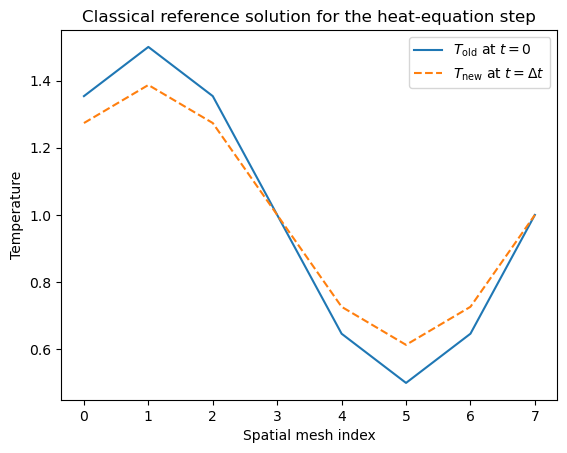

In [4]:
plt.plot(T_old, label=r'$T_\mathrm{old}$ at $t = 0$')
plt.plot(T_new, label=r'$T_\mathrm{new}$ at $t = \Delta t$', linestyle='dashed')
plt.legend()
plt.xlabel('Spatial mesh index')
plt.ylabel('Temperature')
plt.title('Classical reference solution for the heat-equation step')
plt.show()

## 0.2 Normalize the linear system for HHL

HHL acts on normalized quantum states, so we convert the physical linear system into

$A x = b$,

where both $b$ and the target solution $x$ are normalized. This makes it easier to compare the classical finite-difference result with the final quantum output.


In [5]:
# Normalized linear system A * x_th = b

# Normalize the right-hand side coming from the initial temperature profile
TT_old = np.sum(T_old**2)
b0 = np.sqrt(TT_old)
b = T_old / b0

# Normalize the exact classical solution
TT_new = np.sum(T_new**2)
x0 = np.sqrt(TT_new)
x_th = T_new / x0  # normalized reference solution

# Normalized system matrix
f = np.sqrt(TT_new / TT_old)
A = C * f

print("Norm-related quantities used to build the normalized HHL problem:")
print(f"||T_old|| = {b0:.6f}")
print(f"||T_new|| = {x0:.6f}")
print(f"Scaling factor f = sqrt(TT_new / TT_old) = {f:.6f}")

print("\nNormalized right-hand side b:")
print(b)

print("\nNormalized classical solution x_th:")
print(x_th)

Norm-related quantities used to build the normalized HHL problem:
||T_old|| = 3.000000
||T_new|| = 2.932275
Scaling factor f = sqrt(TT_new / TT_old) = 0.977425

Normalized right-hand side b:
[0.45118446 0.5        0.45118446 0.33333333 0.2154822  0.16666667
 0.2154822  0.33333333]

Normalized classical solution x_th:
[0.43429041 0.47291927 0.43429041 0.34103209 0.24777377 0.20914491
 0.24777377 0.34103209]


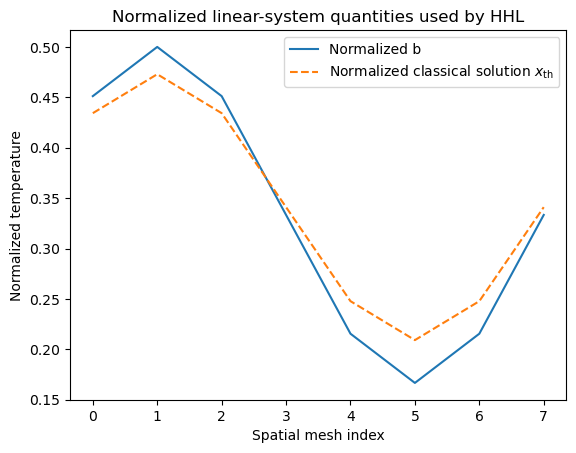

In [6]:
plt.plot(b, label='Normalized b')
plt.plot(x_th, label='Normalized classical solution $x_\mathrm{th}$', linestyle='dashed')
plt.legend()
plt.xlabel('Spatial mesh index')
plt.ylabel('Normalized temperature')
plt.title('Normalized linear-system quantities used by HHL')
plt.show()

## 0.3 Choose the register sizes

Before constructing the circuit, we define the size of each register:

- **input register**: stores the vector to be solved for,
- **clock register**: used by QPE to encode approximate eigenvalues,
- **ancilla**: used by the controlled rotation.

The heat-equation example uses **3 input qubits**, **5 clock qubits** and **1 ancilla qubit**.

In [7]:
n_clock = 5
n_input = n
n_ancilla = 1
n_measurement = n_input + n_ancilla

values_clock = list(range(2**n_clock))
values_clock_bin = [format(v, f'0{n_clock}b') for v in values_clock]

print("Register sizes used in the Qiskit implementation:")
print(f"  input qubits   = {n_input}")
print(f"  clock qubits   = {n_clock}")
print(f"  ancilla qubits = {n_ancilla}")

Register sizes used in the Qiskit implementation:
  input qubits   = 3
  clock qubits   = 5
  ancilla qubits = 1


## 0.4 Spectral quantities used by HHL

The HHL derivation in the manuscript is expressed in terms of the eigenpairs of the normalized matrix.

In the next cells we therefore:

- diagonalize the scaled system matrix,
- inspect the allowed discretized eigenvalue grid of the clock register,
- define the scaling constants needed to relate the normalized quantum solution back to the physical temperature field.

In [8]:
Gamma = C/(1+4*r)

eig_val, eig_vec = scipy.linalg.eigh(Gamma) # Note
eig_val_C, eig_vec_C = scipy.linalg.eigh(C)

# Retain the real part in case of small numerical imaginary residues
eigenvalues = np.real(eig_val)
eigenvectors = np.real(eig_vec)
eigenvalues_C = np.real(eig_val_C)
eigenvectors_C = np.real(eig_vec_C)

# Sort by increasing eigenvalues (optional)
#idx = np.argsort(eigenvalues) # Note !!!!
#eigenvalues = eigenvalues[idx]
#eigenvectors = eigenvectors[:, idx]
#eigenvalues_C = eigenvalues_C[idx]
#eigenvectors_C = eigenvectors_C[:, idx]

eig_val = eigenvalues
eig_vec = eigenvectors
eig_val_C = eigenvalues_C
eig_vec_C = eigenvectors_C

print("Eigenvalues of the original finite-difference matrix C:")
print(" ".join(f"{x:.6f}" for x in eigenvalues_C))
print(f"Expected eigenvalue range for C: from 1.0 to {1 + 4 * r:.6f}")

print("\nEigenvalues of the scaled matrix Gamma = C / (1 + 4r):")
print(" ".join(f"{x:.6f}" for x in eigenvalues))

print(f"\nScaling factor used in A = f * C: f = {f:.6f}")
g = f * (1 + 4 * r)
print(f"Overall scaling factor relating vec(xi) = g * ket(x): g = {g:.6f}")

print("\nClock-register integer values (decimal):")
print(" ".join(f"{x:.0f}" for x in values_clock))

analytical_freq_opt = 1/(pow(2,n_clock)-1)
print("\nClock-register discrete eigenvalue grid (scaled by the analytical frequency):")
print(" ".join(f"{x*analytical_freq_opt:.3f}" for x in values_clock))

print("\n(almost) binarized eigenvalues")
print(" ".join(f"{x*(pow(2,n_clock)-1):.2f}" for x in eigenvalues))

Eigenvalues of the original finite-difference matrix C:
1.000000 1.292893 1.292893 2.000000 2.000000 2.707107 2.707107 3.000000
Expected eigenvalue range for C: from 1.0 to 3.000000

Eigenvalues of the scaled matrix Gamma = C / (1 + 4r):
0.333333 0.430964 0.430964 0.666667 0.666667 0.902369 0.902369 1.000000

Scaling factor used in A = f * C: f = 0.977425
Overall scaling factor relating vec(xi) = g * ket(x): g = 2.932275

Clock-register integer values (decimal):
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31

Clock-register discrete eigenvalue grid (scaled by the analytical frequency):
0.000 0.032 0.065 0.097 0.129 0.161 0.194 0.226 0.258 0.290 0.323 0.355 0.387 0.419 0.452 0.484 0.516 0.548 0.581 0.613 0.645 0.677 0.710 0.742 0.774 0.806 0.839 0.871 0.903 0.935 0.968 1.000

(almost) binarized eigenvalues
10.33 13.36 13.36 20.67 20.67 27.97 27.97 31.00


In [9]:
# Express the normalized vectors in the eigenbasis of Gamma
b_Gamma = inv(eig_vec) @ b
x_Gamma = (1 / g) * (b_Gamma / eig_val)
x_thth = eig_vec @ x_Gamma

print("Normalized classical solution x_th:")
print(x_th)

print("\nSame solution reconstructed spectrally from the eigenbasis:")
print(x_thth)

print(f"\nSanity check, squared norm of the reconstructed vector: {np.sum(np.abs(x_thth)**2):.6f}")

Normalized classical solution x_th:
[0.43429041 0.47291927 0.43429041 0.34103209 0.24777377 0.20914491
 0.24777377 0.34103209]

Same solution reconstructed spectrally from the eigenbasis:
[0.43429041 0.47291927 0.43429041 0.34103209 0.24777377 0.20914491
 0.24777377 0.34103209]

Sanity check, squared norm of the reconstructed vector: 1.000000


## 0.5 Match the true eigenvalues to the discrete clock grid

In QPE, eigenvalues are not stored as arbitrary real numbers. They are encoded through the finite resolution of the clock register.

This means that, once the number of clock qubits is fixed, only a **discrete set of phase values** can be represented exactly.  
The goal of the next cells is therefore to:

1. determine a suitable frequency/time scaling for the QPE evolution,
2. build the corresponding discrete clock grid,
3. identify which clock-register values are the closest to the analytical eigenvalues of the problem.

The helper function below does not change the physics of the example. It is only used to make the comparison between the **continuous analytical eigenvalues** and the **finite-resolution values available to the clock register** more explicit.


In [10]:

def _nearest_cost(t, vc_sorted, ev_sorted):
    """Return the total nearest-neighbour mismatch between true eigenvalues
    and the scaled clock grid t * values_clock.

    A smaller value means that the scaled discrete grid matches the target
    eigenvalues more closely.
    """
    scaled = vc_sorted * t

    # For each target eigenvalue, find where it would be inserted in the
    # sorted scaled grid. This gives the candidate neighbours on the left
    # and on the right.
    idx = np.searchsorted(scaled, ev_sorted)

    # Clip the neighbour indices so they always remain within the valid range.
    idx_left  = np.clip(idx - 1, 0, len(scaled) - 1)
    idx_right = np.clip(idx,     0, len(scaled) - 1)

    # Distance from the closest available discrete clock value.
    dist = np.minimum(
        np.abs(ev_sorted - scaled[idx_left]),
        np.abs(ev_sorted - scaled[idx_right]),
    )
    return dist.sum()


def fit_time(values_clock, eigenvalues, *,
             t_bounds=None,   # optional search interval (t_min, t_max)
             n_grid=1000,     # number of points in each coarse/local scan
             refine=100,      # number of local-refinement iterations
             span=100):       # multiplicative zoom factor around the best t
    """Estimate the scaling factor t that best aligns the discrete clock grid
    with the target analytical eigenvalues.

    Parameters
    ----------
    values_clock : array-like
        Discrete values available from the clock register before scaling.
    eigenvalues : array-like
        Analytical eigenvalues that we want to approximate on the clock grid.
    t_bounds : tuple or None
        Optional positive search interval for t.
    n_grid, refine, span :
        Numerical parameters controlling the coarse search and local refinement.

    Returns
    -------
    t_best : float
        Best scaling factor found by the optimizer.
    c_best : float
        Residual mismatch between the scaled grid and the target eigenvalues.
    """
    vc = np.asarray(values_clock, dtype=float)
    ev = np.asarray(eigenvalues, dtype=float)

    # Remove non-finite values and sort the arrays.
    vc = vc[np.isfinite(vc)]
    ev = ev[np.isfinite(ev)]
    if vc.size == 0 or ev.size == 0:
        raise ValueError("Input arrays are empty or contain no finite values.")

    if np.all(vc == 0):
        raise ValueError("All clock values are zero, cannot estimate a scaling factor.")

    vc_sorted = np.sort(vc)
    ev_sorted = np.sort(ev)

    # If the user does not provide explicit bounds, estimate a broad positive
    # interval from the typical scales of the clock values and eigenvalues.
    if t_bounds is None:
        vmax = np.max(np.abs(vc_sorted))
        evmax = np.max(np.abs(ev_sorted))
        t_min = max(1e-16, 0.1 * evmax / (vmax if vmax > 0 else 1.0))
        t_max = 10.0 * evmax / (vmax if vmax > 0 else 1.0)
    else:
        t_min, t_max = t_bounds
        if t_min <= 0:
            t_min = 1e-12

    # First pass: logarithmic coarse search over a wide interval.
    grid = np.geomspace(t_min, t_max, num=n_grid)
    costs = np.array([_nearest_cost(t, vc_sorted, ev_sorted) for t in grid])
    best_idx = int(np.argmin(costs))
    t_best = float(grid[best_idx])
    c_best = float(costs[best_idx])

    # Second pass: repeated local refinement around the current best value.
    for _ in range(refine):
        lo = max(t_min, t_best / span)
        hi = min(t_max, t_best * span)
        grid = np.geomspace(lo, hi, num=n_grid)
        costs = np.array([_nearest_cost(t, vc_sorted, ev_sorted) for t in grid])
        i = int(np.argmin(costs))
        t_best, c_best = float(grid[i]), float(costs[i])

    return t_best, c_best


# In this notebook we match the first two analytical eigenvalues to the
# available discrete values of the clock register.
eigenvalues_frac = eigenvalues[:2]
freq_opt, cost = fit_time(values_clock, eigenvalues_frac)

print("Frequency scaling proposed by the numerical optimizer:", freq_opt)
print("Residual nearest-neighbour mismatch after optimization:", cost)

# For consistency with the analytical derivation used in the manuscript,
# we keep using the analytical frequency selected in the text.
freq_opt = analytical_freq_opt
print("Frequency scaling adopted in the tutorial (analytical choice):", freq_opt)

# Convert the selected frequency into the evolution time used in QPE.
time = 2 * np.pi / (pow(2, n_clock) * freq_opt)
print("Corresponding QPE evolution time:", time)

# This is the discrete clock grid after applying the selected scaling.
scaled = np.array(values_clock) * freq_opt
print("Scaled discrete clock grid constructed successfully.")


Frequency scaling proposed by the numerical optimizer: 0.019598771890282342
Residual nearest-neighbour mismatch after optimization: 0.0003627865135945041
Frequency scaling adopted in the tutorial (analytical choice): 0.03225806451612903
Corresponding QPE evolution time: 6.086835766330224
Scaled discrete clock grid constructed successfully.


### Interpreting the result

At this point we have:
- the **analytical eigenvalues** coming from the classical spectral decomposition,
- the **scaled discrete clock grid** that can actually be represented by the QPE register.

The next cells perform the one-to-one comparison and reports, for each analytical eigenvalue:
- the nearest discrete value,
- its decimal and binary clock-register index,
- the corresponding relative approximation error.


In [11]:
# Find the nearest discrete clock-register value for each analytical eigenvalue
nearest_idx = [np.argmin(np.abs(scaled - e)) for e in eigenvalues]
nearest = [scaled[i] for i in nearest_idx]

print("Matching between analytical eigenvalues and the nearest 5-qubit clock values:")
for e, nval, i in zip(eigenvalues, nearest, nearest_idx):
    rel_err = (e - nval) / e * 100 if e != 0 else 0.0
    print(
        f"  eigenvalue = {e:.6f} -> nearest discrete value = {nval:.6f} "
        f"(decimal index = {i:d}, binary index = {i:0{n_clock}b}, relative error = {rel_err:.2f}%)"
    )

Matching between analytical eigenvalues and the nearest 5-qubit clock values:
  eigenvalue = 0.333333 -> nearest discrete value = 0.322581 (decimal index = 10, binary index = 01010, relative error = 3.23%)
  eigenvalue = 0.430964 -> nearest discrete value = 0.419355 (decimal index = 13, binary index = 01101, relative error = 2.69%)
  eigenvalue = 0.430964 -> nearest discrete value = 0.419355 (decimal index = 13, binary index = 01101, relative error = 2.69%)
  eigenvalue = 0.666667 -> nearest discrete value = 0.677419 (decimal index = 21, binary index = 10101, relative error = -1.61%)
  eigenvalue = 0.666667 -> nearest discrete value = 0.677419 (decimal index = 21, binary index = 10101, relative error = -1.61%)
  eigenvalue = 0.902369 -> nearest discrete value = 0.903226 (decimal index = 28, binary index = 11100, relative error = -0.09%)
  eigenvalue = 0.902369 -> nearest discrete value = 0.903226 (decimal index = 28, binary index = 11100, relative error = -0.09%)
  eigenvalue = 1.00000

In [12]:
print("Example, nearest clock index associated with the first eigenvalue:")
print(nearest_idx[0])

Example, nearest clock index associated with the first eigenvalue:
10


In [13]:
# Build the approximate eigenvalue vector from the nearest clock values
approx_eigenvalues = np.array([scaled[np.argmin(np.abs(scaled - e))] for e in eigenvalues])

print("Exact analytical eigenvalues:")
print(" ".join(f"{x:.4f}" for x in eigenvalues))

print("\nDiscrete eigenvalues actually available to QPE:")
print(" ".join(f"{x:.4f}" for x in approx_eigenvalues))

np.set_printoptions(precision=4, suppress=True)

Exact analytical eigenvalues:
0.3333 0.4310 0.4310 0.6667 0.6667 0.9024 0.9024 1.0000

Discrete eigenvalues actually available to QPE:
0.3226 0.4194 0.4194 0.6774 0.6774 0.9032 0.9032 1.0000


In [14]:
print("Dimensionless clock indices associated with the discretized eigenvalues (lambda_tilde):")
print(" ".join(f"{x:.4f}" for x in approx_eigenvalues / freq_opt))

Dimensionless clock indices associated with the discretized eigenvalues (lambda_tilde):
10.0000 13.0000 13.0000 21.0000 21.0000 28.0000 28.0000 31.0000


In [15]:
# Build the diagonal matrix with the discretized eigenvalues
Lambda_new = np.diag(approx_eigenvalues)

# Reconstruct A' = V * Λ' * V^{-1}
A_approx = eig_vec @ Lambda_new @ la.inv(eig_vec)

# Force A' to be real when numerical noise is negligible
A_approx = np.real_if_close(A_approx)*(1+4*r)

In [16]:
print("Approximate matrix reconstructed from the discretized eigenvalues, A_approx:")
print(A_approx)

Approximate matrix reconstructed from the discretized eigenvalues, A_approx:
[[ 1.996  -0.5106 -0.0121  0.0026  0.0121  0.0026 -0.0121 -0.5106]
 [-0.5106  1.996  -0.5106 -0.0121  0.0026  0.0121  0.0026 -0.0121]
 [-0.0121 -0.5106  1.996  -0.5106 -0.0121  0.0026  0.0121  0.0026]
 [ 0.0026 -0.0121 -0.5106  1.996  -0.5106 -0.0121  0.0026  0.0121]
 [ 0.0121  0.0026 -0.0121 -0.5106  1.996  -0.5106 -0.0121  0.0026]
 [ 0.0026  0.0121  0.0026 -0.0121 -0.5106  1.996  -0.5106 -0.0121]
 [-0.0121  0.0026  0.0121  0.0026 -0.0121 -0.5106  1.996  -0.5106]
 [-0.5106 -0.0121  0.0026  0.0121  0.0026 -0.0121 -0.5106  1.996 ]]


### Check the effect of eigenvalue discretization

The following comparison shows how well the solution obtained from the **discretized eigenvalues** reproduces the exact normalized classical solution.

This is useful because the HHL circuit will only have access to the discretized approximation, not to the exact continuous eigenvalues.

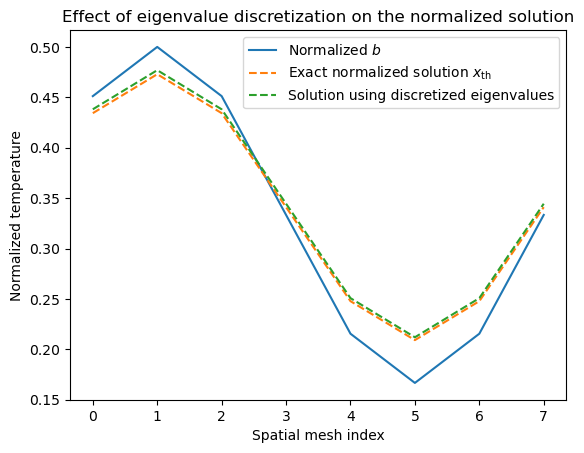

In [17]:
x_th2 = inv(A_approx) @ b

plt.plot(b, label=r'Normalized $b$')
plt.plot(x_th, label=r'Exact normalized solution $x_\mathrm{th}$', linestyle='dashed')
plt.plot(x_th2, label=r'Solution using discretized eigenvalues', linestyle='dashed')
plt.legend()
plt.xlabel('Spatial mesh index')
plt.ylabel('Normalized temperature')
plt.title('Effect of eigenvalue discretization on the normalized solution')
plt.show()

# Step 1, Construct the HHL circuit block by block

From this point on, the notebook follows the same logical order as the HHL derivation:

1. prepare the clock superposition,
2. apply controlled exponentials,
3. perform inverse QFT to complete QPE,
4. inspect the QPE output,
5. apply the controlled rotation for inversion,
6. uncompute QPE,
7. post-select the ancilla and reconstruct the solution.


## 1.1 Condition number

We first print the condition number of the normalized matrix $A$. This is one of the key quantities controlling the difficulty of the linear-system problem.

In [18]:
kappa = np.linalg.cond(A)
print(f"Condition number of the normalized matrix A: kappa = {kappa:.6f}")

Condition number of the normalized matrix A: kappa = 3.000000


## 1.2 Convert the matrix exponential into a Qiskit gate

HHL requires controlled applications of $e^{iAt}$ (or of the scaled matrix used in the notebook). The helper function below takes the chosen matrix and evolution time and converts the exponential into a Qiskit `UnitaryGate`.

In [19]:
def convert_A_to_gate(A, T):
    # convert to unitary matrix through exponentiation
    U_mat = scipy.linalg.expm(1j*A*T)

    # convert to a unitary operator with Qiskit
    U = UnitaryGate(U_mat)
    U.name = "$U$"
    return U

## 1.3 Create the registers and initialize the full circuit

The circuit is built explicitly from separate registers so that it is always clear which qubits belong to:

- the clock,
- the input system,
- the ancilla,
- and the optional classical readout.

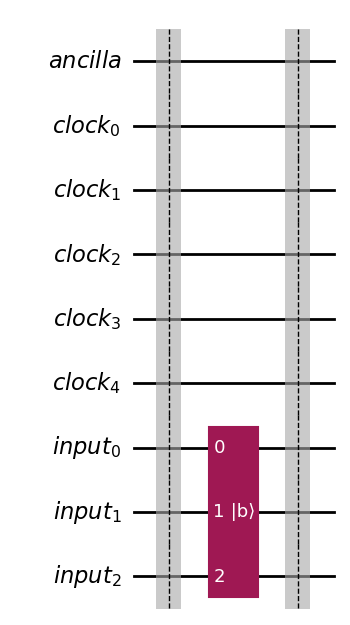

In [20]:
clock = QuantumRegister(n_clock, 'clock')
input = QuantumRegister(n_input, 'input')
ancilla = QuantumRegister(n_ancilla, 'ancilla')
measurement = ClassicalRegister(n_measurement, 'measurement')

# Create an empty circuit with the required registers
circuit_shot = QuantumCircuit(ancilla, clock, input) #, measurement)

circuit_shot.barrier()

init_subcircuit = QuantumCircuit(n_input, name=' |b⟩')
init_subcircuit.initialize(b)
list_input = list(range(n_clock+1, n_clock+n_input+1))
circuit_shot.append(init_subcircuit.to_instruction(), list_input)

circuit_shot.barrier()

circuit_shot.draw(output='mpl')

# Quantum Phase Estimation (QPE)
## 1.4 Put the clock register in uniform superposition

This is the standard starting point of QPE. Applying Hadamards to all clock qubits prepares the equal superposition over the computational basis states of the clock register.

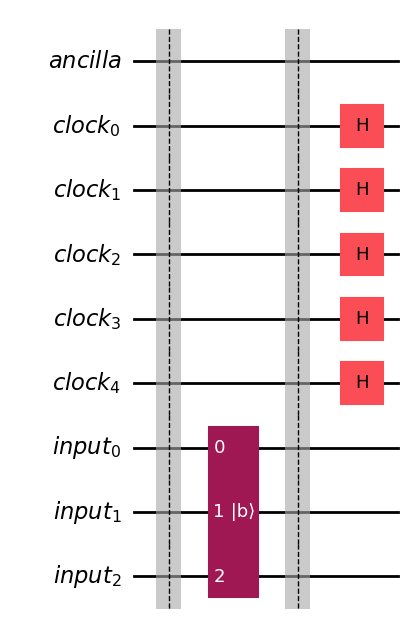

In [21]:
# Apply Hadamard gates to the clock register
circuit_shot.h(clock)

# circuit_shot.barrier()

circuit_shot.draw(output='mpl')

## 1.5 Controlled matrix exponentiation

This is the controlled-$U^{2^k}$ part of QPE. The circuit below assembles the controlled exponentials that imprint the eigenvalue-dependent phases onto the clock register.

In [22]:
# --- Controlled-U stage ---

U = convert_A_to_gate(Gamma, time) # Note

circuit_expAt = QuantumCircuit(clock, input, name=' C-exp')

shifted_list_input = [x - 1 for x in list_input]

for i in range(n_clock): 
    Upow = U.power(2**i) 
    ctrl_Upow = Upow.control() 
    circuit_expAt.append(ctrl_Upow, [i, *shifted_list_input])

# circuit_expAt.draw(output='mpl')
gate_expAt = circuit_expAt.to_gate()

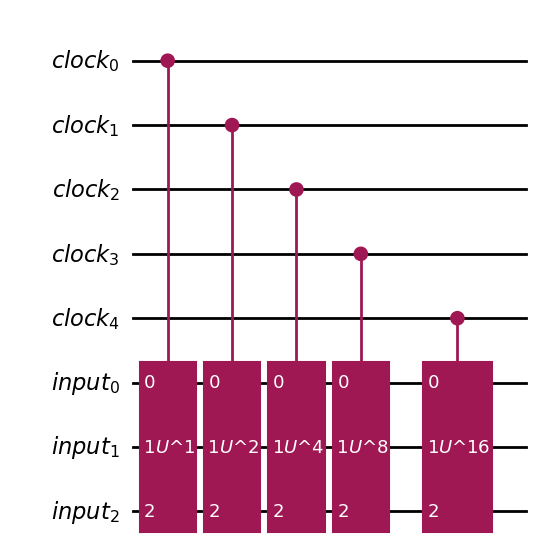

In [23]:
circuit_expAt.draw(output='mpl')

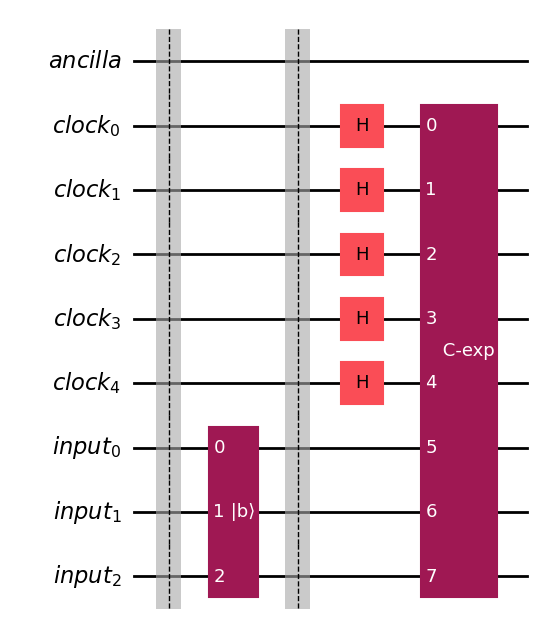

In [24]:
append_exponentiation = [i for i in range(1, n_clock + n_input +1)]
circuit_shot.append(gate_expAt, append_exponentiation)

# circuit_shot.barrier()

circuit_shot.draw(output='mpl')

## 1.6 Apply the inverse QFT

After the controlled exponentials, the inverse QFT converts the phase information accumulated in the clock register into a binary approximation of the eigenvalues.

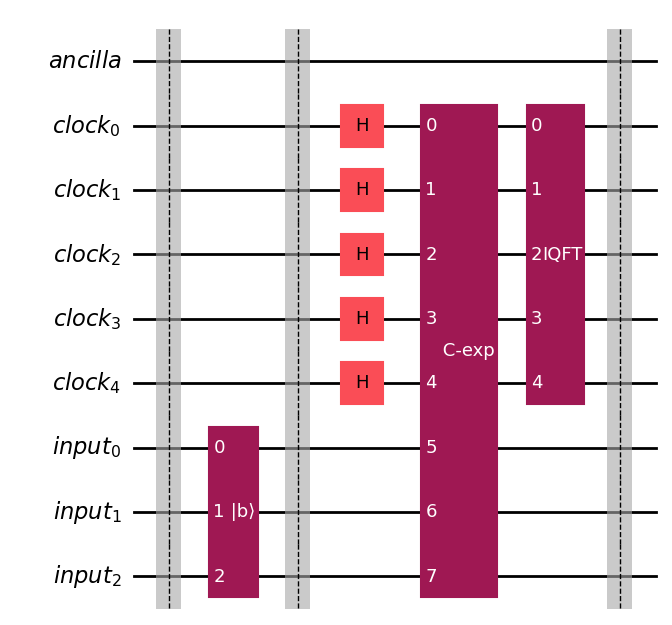

In [25]:
# --- Inverse QFT ---
iqft = QFT(n_clock, inverse=True)
circuit_shot.append(iqft, clock)

circuit_shot.barrier()

circuit_shot.draw(output='mpl')

# Step 2, Analyze $\Psi_4$, the output of QPE

At this stage the circuit contains the QPE output, before the HHL inversion step is applied.

The next cells inspect the corresponding statevector and compare the clock-register probability distribution against simple theoretical reconstructions. This is one of the most instructive checkpoints in the whole notebook, because it shows whether the eigenvalue encoding is behaving as expected.


In [47]:
statevector = Statevector.from_instruction(circuit_shot)
ideal_distribution = statevector.probabilities_dict()

Psi4 = statevector

# Extract the full statevector amplitudes for the completed HHL circuit
amps = statevector.data

## 2.1 Marginalize over the input and ancilla registers

To understand QPE, we are mainly interested in the probability distribution on the **clock register**. The helper function below extracts that marginal distribution from the full statevector probabilities.

In [27]:
def marginalize_clock(ideal_distribution, n_input, n_clock, n_ancilla=1):
    """
    Build the marginal probability distribution of the clock register.
    The assumed bitstring layout is:
        [input][clock][ancilla]

    This convention should be kept in mind when slicing the bitstrings.
    """

    grouped_probs = defaultdict(float)

    for bitstr, p in ideal_distribution.items():
        # Extract only the clock-register substring and accumulate its probability
        clock_bits = bitstr[n_input:n_input + n_clock]
        grouped_probs[clock_bits] += float(p)

    # Renormalize for numerical safety
    total = sum(grouped_probs.values())
    if total > 0:
        for k in grouped_probs:
            grouped_probs[k] /= total

    # Sort by increasing binary value for easier interpretation and plotting
    grouped_probs = dict(sorted(grouped_probs.items(), key=lambda kv: int(kv[0], 2)))

    return grouped_probs


def print_clock_distribution(clock_dist):
    """Pretty-print the clock-register marginal distribution."""
    print("Clock state  |  Marginal probability")
    print("------------------------------------")
    for k, p in clock_dist.items():
        print(f"   {k}      |  {p:.6f}")


In [28]:
clock_dist = marginalize_clock(ideal_distribution, n_input, n_clock)
print("Sanity check, total probability in the marginalized clock distribution:")
print(sum(clock_dist.values()))

Sanity check, total probability in the marginalized clock distribution:
1.0


The next cell reports, for each eigencomponent $j$:
- the nearest discrete clock index selected by the QPE discretization,
- and the corresponding expected weight of that component.

This helps connect the analytical eigendecomposition to the histogram that QPE will produce on the finite clock register.

In [29]:
for j in range(N):
    eigen_j_approx = nearest_idx[j]
    prob_eigen_j = np.sum(np.abs(eig_vec[:, j] * b_Gamma[j])**2)
    print(
        f"Eigencomponent j = {j}: "
        f"nearest clock index = {eigen_j_approx}, "
        f"expected contribution to the clock distribution = {prob_eigen_j:.6f}"
    )

Eigencomponent j = 0: nearest clock index = 10, expected contribution to the clock distribution = 0.888889
Eigencomponent j = 1: nearest clock index = 13, expected contribution to the clock distribution = 0.055556
Eigencomponent j = 2: nearest clock index = 13, expected contribution to the clock distribution = 0.055556
Eigencomponent j = 3: nearest clock index = 21, expected contribution to the clock distribution = 0.000000
Eigencomponent j = 4: nearest clock index = 21, expected contribution to the clock distribution = 0.000000
Eigencomponent j = 5: nearest clock index = 28, expected contribution to the clock distribution = 0.000000
Eigencomponent j = 6: nearest clock index = 28, expected contribution to the clock distribution = 0.000000
Eigencomponent j = 7: nearest clock index = 31, expected contribution to the clock distribution = 0.000000


We now construct a first theoretical clock-register model by assigning each eigencomponent to its nearest clock-grid point and accumulating the corresponding weight. This is the most direct theory-side analogue of the QPE output.

In [30]:
clock_dist_theory = {k: 0 for k in clock_dist}

for j in range(N):
    eigen_j_approx = nearest_idx[j]
    key_j = format(eigen_j_approx, f"0{n_clock}b")
    clock_dist_theory[key_j] += np.sum(np.abs(eig_vec[:, j] * b_Gamma[j])**2)

print("First theoretical clock model:")
print_clock_distribution(clock_dist_theory)

print("\nSanity check:")
print(f"Total probability in the first theoretical clock model = {sum(clock_dist_theory.values()):.6f}")

First theoretical clock model:
Clock state  |  Marginal probability
------------------------------------
   00000      |  0.000000
   00001      |  0.000000
   00010      |  0.000000
   00011      |  0.000000
   00100      |  0.000000
   00101      |  0.000000
   00110      |  0.000000
   00111      |  0.000000
   01000      |  0.000000
   01001      |  0.000000
   01010      |  0.888889
   01011      |  0.000000
   01100      |  0.000000
   01101      |  0.111111
   01110      |  0.000000
   01111      |  0.000000
   10000      |  0.000000
   10001      |  0.000000
   10010      |  0.000000
   10011      |  0.000000
   10100      |  0.000000
   10101      |  0.000000
   10110      |  0.000000
   10111      |  0.000000
   11000      |  0.000000
   11001      |  0.000000
   11010      |  0.000000
   11011      |  0.000000
   11100      |  0.000000
   11101      |  0.000000
   11110      |  0.000000
   11111      |  0.000000

Sanity check:
Total probability in the first theoretical clock

This second model is slightly simpler: it uses only the spectral coefficients $|b_j^\Gamma|^2 $, without the additional weighting introduced by the eigenvector entries in the previous expression. Comparing the two models is useful pedagogically, because it shows which theoretical ingredients matter for reproducing the observed QPE distribution.

In [31]:
clock_dist_theory2 = {k: 0 for k in clock_dist}

for j in range(N):
    eigen_j_approx = nearest_idx[j]
    key_j = format(eigen_j_approx, f"0{n_clock}b")
    clock_dist_theory2[key_j] += np.sum(np.abs(b_Gamma[j])**2)  # spectral weight |b_j^Gamma|^2

print("Second theoretical clock model:")
print_clock_distribution(clock_dist_theory2)

print("\nSanity check:")
print(f"Total probability in the second theoretical clock model = {sum(clock_dist_theory2.values()):.6f}")

Second theoretical clock model:
Clock state  |  Marginal probability
------------------------------------
   00000      |  0.000000
   00001      |  0.000000
   00010      |  0.000000
   00011      |  0.000000
   00100      |  0.000000
   00101      |  0.000000
   00110      |  0.000000
   00111      |  0.000000
   01000      |  0.000000
   01001      |  0.000000
   01010      |  0.888889
   01011      |  0.000000
   01100      |  0.000000
   01101      |  0.111111
   01110      |  0.000000
   01111      |  0.000000
   10000      |  0.000000
   10001      |  0.000000
   10010      |  0.000000
   10011      |  0.000000
   10100      |  0.000000
   10101      |  0.000000
   10110      |  0.000000
   10111      |  0.000000
   11000      |  0.000000
   11001      |  0.000000
   11010      |  0.000000
   11011      |  0.000000
   11100      |  0.000000
   11101      |  0.000000
   11110      |  0.000000
   11111      |  0.000000

Sanity check:
Total probability in the second theoretical clo

The third model writes the same idea more explicitly, by looping over every possible clock state $k$ and checking whether it matches the discretized eigenvalue index associated with each eigencomponent $j$. In practice, this is equivalent to a delta-selection rule on the finite clock grid.

This formulation is more verbose than the previous one, but it is useful because it mirrors the analytical expression more directly.

In [32]:
clock_dist_theory3 = {k: 0 for k in clock_dist}

for k in range(2**n_clock):
    k_bin = format(k, f"0{n_clock}b")

    probability = 0
    for j in range(N):
        k_lambda_j = nearest_idx[j]

        # Kronecker-delta selection:
        # contribute only when the current clock state k matches the
        # discretized clock index associated with eigencomponent j
        if k == k_lambda_j:
            delta = 1
        else:
            delta = 0

        probability += np.abs(delta * b_Gamma[j])**2

    clock_dist_theory3[k_bin] = probability

print("Third theoretical clock model:")
print_clock_distribution(clock_dist_theory3)

print("\nSanity check:")
print(f"Total probability in the third theoretical clock model = {sum(clock_dist_theory3.values()):.6f}")

Third theoretical clock model:
Clock state  |  Marginal probability
------------------------------------
   00000      |  0.000000
   00001      |  0.000000
   00010      |  0.000000
   00011      |  0.000000
   00100      |  0.000000
   00101      |  0.000000
   00110      |  0.000000
   00111      |  0.000000
   01000      |  0.000000
   01001      |  0.000000
   01010      |  0.888889
   01011      |  0.000000
   01100      |  0.000000
   01101      |  0.111111
   01110      |  0.000000
   01111      |  0.000000
   10000      |  0.000000
   10001      |  0.000000
   10010      |  0.000000
   10011      |  0.000000
   10100      |  0.000000
   10101      |  0.000000
   10110      |  0.000000
   10111      |  0.000000
   11000      |  0.000000
   11001      |  0.000000
   11010      |  0.000000
   11011      |  0.000000
   11100      |  0.000000
   11101      |  0.000000
   11110      |  0.000000
   11111      |  0.000000

Sanity check:
Total probability in the third theoretical clock

## 2.2 Compare QPE against theory

The following histograms compare the clock-register distribution produced by QPE with progressively simplified theoretical models. The goal is not only to verify correctness, but also to make clear which approximation is being used in each comparison.

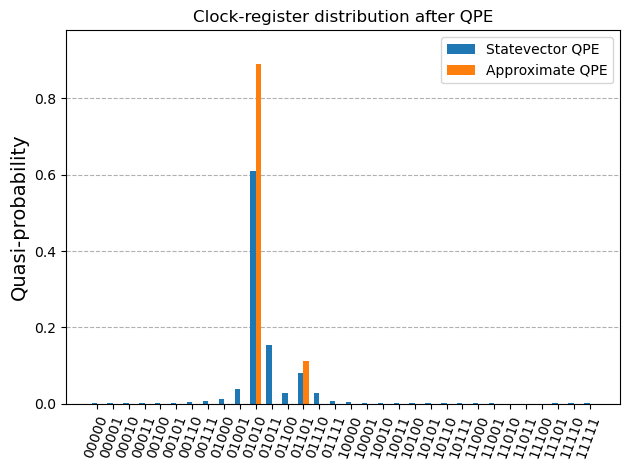

In [33]:
fig, ax = plt.subplots()

plot_histogram(
    [clock_dist, clock_dist_theory],
    legend=["Statevector QPE", "Approximate QPE"],
    bar_labels=False,
    ax=ax
)

ax.legend(loc="upper right")
ax.set_title("Clock-register distribution after QPE")
fig.tight_layout()
plt.show()

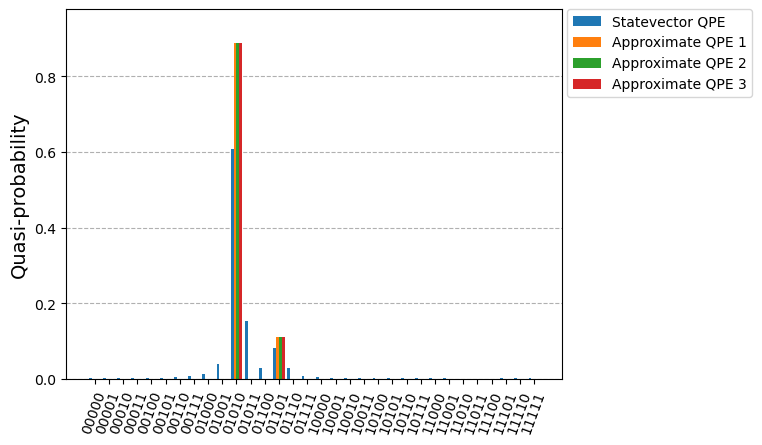

In [34]:
plot_histogram([clock_dist, clock_dist_theory, clock_dist_theory2, clock_dist_theory3], 
               legend=["Statevector QPE", "Approximate QPE 1", "Approximate QPE 2", "Approximate QPE 3"], bar_labels=False)

## 2.3 Reorganize the QPE probabilities as a matrix

It is often easier to inspect the QPE output in matrix form, with:

- one index for the eigenvector / input component,
- one index for the discretized clock value.

This representation is useful because it separates the role of the **input register** from that of the **clock register**, and it will also be reused in the consistency checks below.

In [35]:
def probs_matrix_from_dict(ideal_distribution, n, n_clock, n_ancilla=1, assume_probs=True):
    """
    Reorganize the full QPE output into a matrix P[j, k].

    Notes
    -----
    The bitstring convention used here is:
        [input][clock][ancilla]
    """

    # Cast indices to Python integers in case they are NumPy scalars
    n = int(n)
    n_clock = int(n_clock)
    n_ancilla = int(n_ancilla)

    dim_j = 2**n
    dim_k = 2**n_clock

    # Output matrix: rows = input states, columns = clock states
    P = np.zeros((dim_j, dim_k), dtype=float)

    for bitstr, value in ideal_distribution.items():
        b = str(bitstr)  # garantisce che sia una vera stringa

        expected_len = n + n_clock + n_ancilla
        if len(b) != expected_len:
            raise ValueError(f"Bitstring {b} ha lunghezza {len(b)}, ma mi aspetto {expected_len}.")

        # Split the full bitstring into input, clock, and ancilla substrings
        input_bits = b[:n]
        clock_bits = b[n:n + n_clock]
        ancilla_bits = b[n + n_clock:]

        # Consider only the ancilla = 0...0 sector
        if ancilla_bits != '0' * n_ancilla:
            continue

        # Convert the input and clock substrings into decimal indices
        j_dec = int(input_bits, 2)
        k_dec = int(clock_bits, 2)

        # Use the supplied probability directly, or convert an amplitude into probability
        p = float(value) if assume_probs else float(np.abs(value)**2)

        # Sum over ancilla states by accumulating into the same (j, k) entry
        P[j_dec, k_dec] += p

    return P


In [36]:
print("Sanity check: total probability in the full QPE distribution")
print(sum(ideal_distribution.values()))

Sanity check: total probability in the full QPE distribution
0.9999999999999013


In [37]:
p_Psi4 = probs_matrix_from_dict(
    ideal_distribution, n_input, n_clock, n_ancilla, assume_probs=True
    )
print("Shape of the probability matrix p_Psi4 = (input index, clock index):")
print(p_Psi4.shape)

Shape of the probability matrix p_Psi4 = (input index, clock index):
(8, 32)


In [38]:
# Recover the clock-register marginal by summing the matrix over the input index j
clock_dist3 = {k: 0 for k in clock_dist}

for k in range(2**n_clock):
    probability = 0
    for j in range(N):
        probability += p_Psi4[j][k]

    key_k = format(k, f"0{n_clock}b")
    clock_dist3[key_k] = probability

print("Clock-register marginal rebuilt from p_Psi4:")
print_clock_distribution(clock_dist3)

Clock-register marginal rebuilt from p_Psi4:
Clock state  |  Marginal probability
------------------------------------
   00000      |  0.000998
   00001      |  0.001136
   00010      |  0.001332
   00011      |  0.001620
   00100      |  0.002059
   00101      |  0.002770
   00110      |  0.004025
   00111      |  0.006561
   01000      |  0.012978
   01001      |  0.038729
   01010      |  0.608991
   01011      |  0.153883
   01100      |  0.029547
   01101      |  0.080886
   01110      |  0.027765
   01111      |  0.006783
   10000      |  0.003687
   10001      |  0.002483
   10010      |  0.001852
   10011      |  0.001473
   10100      |  0.001227
   10101      |  0.001059
   10110      |  0.000943
   10111      |  0.000861
   11000      |  0.000805
   11001      |  0.000770
   11010      |  0.000751
   11011      |  0.000748
   11100      |  0.000759
   11101      |  0.000787
   11110      |  0.000832
   11111      |  0.000901


This block refines the previous clock-register models by including the finite resolution of QPE.  
Instead of assigning each eigenvalue to a single clock bin, it distributes its contribution over the discrete clock grid.

In [39]:
# Number of basis states of the clock register
Nc = 2**n_clock

# Theoretical clock-register distribution including finite-QPE resolution effects
clock_dist4 = {k: 0 for k in clock_dist}

# Store the complex QPE amplitudes, with and without the spectral coefficient b_Gamma[j]
alphaalpha_Psi4 = np.zeros((N, Nc), dtype=complex)
alpha_Psi4 = np.zeros((N, Nc), dtype=complex)

for k in range(Nc):                   # current clock state (decimal)
    k_bin = format(k, f"0{n_clock}b") # same clock state written as a bitstring

    probability = 0
    for j in range(N):                # eigencomponent index
        k_lambda_j = nearest_idx[j]   # nearest clock-grid point for eigenvalue j

        # Distance between the current clock index k and the ideal encoded phase
        m = eigenvalues[j] * (Nc - 1) - k

        # Finite-size QPE kernel on the discrete clock grid
        result = np.sin(np.pi * m) / (Nc * np.sin(np.pi * m / Nc))

        if k == k_lambda_j:
            k_lambda_j_bin = format(k_lambda_j, f"0{n_clock}b")
            print(
                f'Eigenvalue {eigenvalues[j]:.6f} is approximated by '
                f'clock index {k_lambda_j} (bitstring {k_lambda_j_bin})'
            )

        # Full complex amplitude, with and without the spectral weight b_Gamma[j]
        alphaalpha_Psi4[j][k] = (
            np.exp(1j * np.pi * (Nc - 1) * m / Nc)
            * np.sin(np.pi * m)
            / (Nc * np.sin(np.pi * m / Nc))
            * b_Gamma[j]
        )
        alpha_Psi4[j][k] = (
            np.exp(1j * np.pi * (Nc - 1) * m / Nc)
            * np.sin(np.pi * m)
            / (Nc * np.sin(np.pi * m / Nc))
        )

        # Add the contribution of eigencomponent j to clock outcome k
        probability += (np.abs(result) * np.abs(b_Gamma[j]))**2

    clock_dist4[k_bin] = probability

Eigenvalue 0.333333 is approximated by clock index 10 (bitstring 01010)
Eigenvalue 0.430964 is approximated by clock index 13 (bitstring 01101)
Eigenvalue 0.430964 is approximated by clock index 13 (bitstring 01101)
Eigenvalue 0.666667 is approximated by clock index 21 (bitstring 10101)
Eigenvalue 0.666667 is approximated by clock index 21 (bitstring 10101)
Eigenvalue 0.902369 is approximated by clock index 28 (bitstring 11100)
Eigenvalue 0.902369 is approximated by clock index 28 (bitstring 11100)
Eigenvalue 1.000000 is approximated by clock index 31 (bitstring 11111)


In [40]:
print("Example slice of |alpha_Psi4| for j = 0 and a few clock values:")
print(np.abs(alpha_Psi4[0][8:12]))

Example slice of |alpha_Psi4| for j = 0 and a few clock values:
[0.1192 0.2073 0.8271 0.4138]


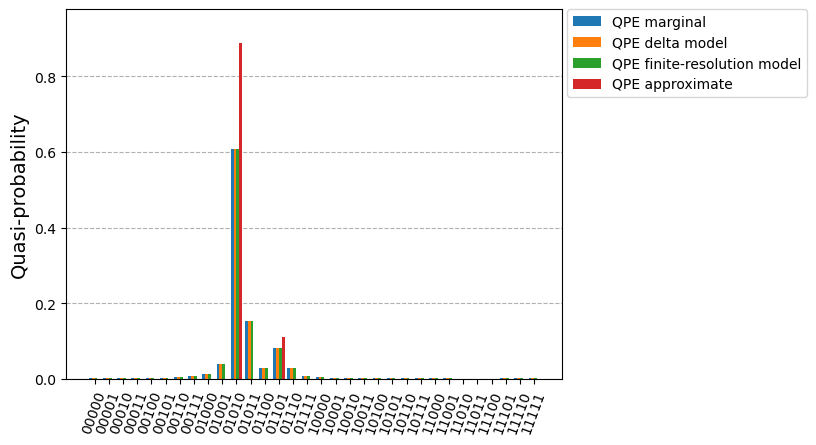

In [ ]:
plot_histogram(
    [clock_dist, clock_dist4, clock_dist3, clock_dist_theory],
    legend=[
        "QPE marginal",
        "Theory, finite-resolution model",
        "QPE marginal rebuilt from p_Psi4",
        "Theory, nearest-bin model",
    ],
    bar_labels=False
)

## 2.4 Inspect the contribution of each eigencomponent separately

The next plots separate the different $j$ contributions, making it easier to see how each eigencomponent populates the clock register.

This is useful because the full QPE distribution is a superposition of these individual contributions.

j = 0, total probability = 1.0000000000000002
j = 1, total probability = 1.0000000000000004
j = 2, total probability = 1.0000000000000002
j = 3, total probability = 1.0
j = 4, total probability = 1.0000000000000004
j = 5, total probability = 1.0
j = 6, total probability = 1.0000000000000004
j = 7, total probability = 1.0


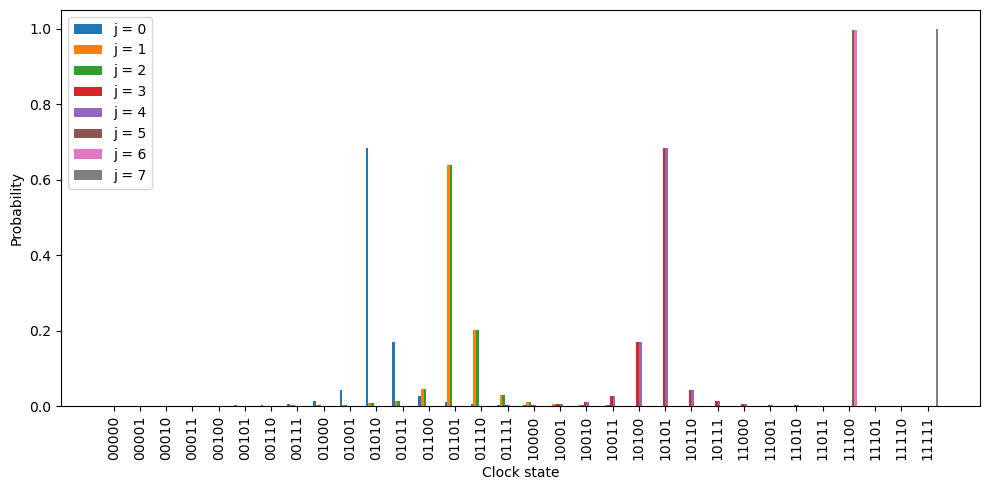

In [41]:
# One bar group per clock state, with one bar for each eigencomponent j
labels = [format(k, f"0{n_clock}b") for k in range(Nc)]
x = np.arange(Nc)
width = 0.8 / N

plt.figure(figsize=(10, 5))

for j in range(N):
    y = []

    for k in range(Nc):
        # Finite-resolution contribution of eigencomponent j to clock state k
        m = eigenvalues[j] * (Nc - 1) - k
        result = np.sin(np.pi * m) / (Nc * np.sin(np.pi * m / Nc))
        prob = (np.abs(result))**2
        y.append(prob)

    print(f"j = {j}, total probability = {sum(y)}")

    # Shift the bars associated with j so that they appear side by side
    plt.bar(x + j * width, y, width=width, label=f'j = {j}')

plt.xticks(x + width * (N - 1) / 2, labels, rotation=90)
plt.xlabel("Clock state")
plt.ylabel("Probability")
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
print("Example of the ideal encoded clock value for j = 0:")
print((Nc - 1) * eigenvalues[0])

Example of the ideal encoded clock value for j = 0:
10.33333333333333


In [43]:
# Build one theoretical clock distribution for each eigencomponent j separately
clock_dists = []

for j in range(N):
    clock_dist_j = {k: 0 for k in clock_dist}

    for k in range(Nc):
        k_bin = format(k, f"0{n_clock}b")

        # Finite-resolution response of the j-th eigencomponent on the clock grid
        m = eigenvalues[j] * (Nc - 1) - k
        result = np.sin(np.pi * m) / (Nc * np.sin(np.pi * m / Nc))

        clock_dist_j[k_bin] = (np.abs(result))**2

    clock_dists.append(clock_dist_j.copy())

Clock distribution for the first eigencomponent only:
{'00000': np.float64(0.0010156383808137314), '00001': np.float64(0.0011636650682232766), '00010': np.float64(0.0013749196992301645), '00011': np.float64(0.0016847474149223791), '00100': np.float64(0.002158751762146669), '00101': np.float64(0.002929687499999972), '00110': np.float64(0.004300090281968177), '00111': np.float64(0.0070886398650936155), '01000': np.float64(0.014204234377706262), '01001': np.float64(0.042989853911851075), '01010': np.float64(0.6841621825107208), '01011': np.float64(0.171223847327931), '01100': np.float64(0.027602173060981665), '01101': np.float64(0.010933742600299298), '01110': np.float64(0.005902815174016634), '01111': np.float64(0.003744118956084812), '10000': np.float64(0.0026265268864194245), '10001': np.float64(0.001976364530578912), '10010': np.float64(0.001567353578654023), '10011': np.float64(0.0012957185424633329), '10100': np.float64(0.0011085212667414366), '10101': np.float64(0.00097656249999998

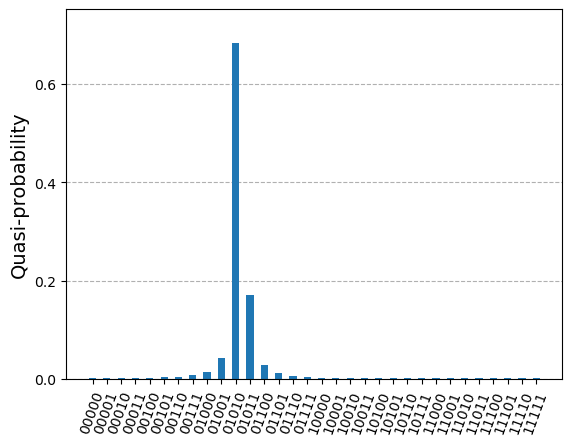

In [44]:
print("Clock distribution for the first eigencomponent only:")
print(clock_dists[0])
plot_histogram(clock_dists[0], bar_labels=False)

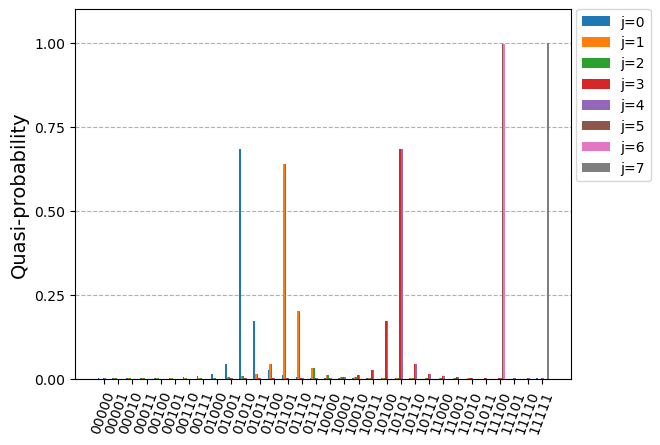

In [45]:
labels = [f"j={j}" for j in range(N)]
plot_histogram(clock_dists, bar_labels=False, legend=labels)

# Step 3, Apply the inversion stage and complete the HHL circuit

Up to this point, we have analyzed the output of the **QPE block** in isolation.  
We now move to the actual HHL routine:

1. apply the controlled rotation used to encode the inverse eigenvalues,
2. uncompute the clock register with inverse QPE,
3. inspect the final statevector,
4. post-select the ancilla-success branch,
5. reconstruct the solution on the input register.

In [46]:
# N = 2**n_input
# Nc = 2**n_clock
# eig_vec: eigenvector matrix, shape (N, N)
# alphaalpha_Psi4: theoretical QPE amplitudes weighted by b_Gamma, shape (N, Nc)

# 1) Theoretical amplitudes for ancilla = 0:
#    B[x, k] = sum_j eig_vec[x, j] * alphaalpha_Psi4[j, k]
B = eig_vec @ alphaalpha_Psi4

# 2) Build the full (input, clock, ancilla) tensor
psi_th_tensor = np.zeros((N, Nc, 2), dtype=complex)
psi_th_tensor[:, :, 0] = B   # ancilla = 0
# The ancilla = 1 sector remains zero at this stage

# 3) Flatten the tensor into a single statevector with ordering (input, clock, ancilla)
psi_th = psi_th_tensor.reshape(-1)

In [48]:
# Compare the theoretical statevector built above with the Qiskit statevector Psi4
psi4_vec = Psi4.data

print("Type of the Qiskit statevector container:")
print(type(psi4_vec))

# The two vectors must have the same shape before a pointwise comparison
assert psi_th.shape == psi4_vec.shape, f"{psi_th.shape} vs {psi4_vec.shape}"

diff = psi_th - psi4_vec

max_abs_diff = np.max(np.abs(diff))
norm_diff = np.linalg.norm(diff)

print("Maximum pointwise difference =", max_abs_diff)
print("Norm of the difference =", norm_diff)

# Print only entries that differ above the chosen tolerance
toll = 1e-10
for idx, d in enumerate(diff):
    if np.abs(d) > toll:
        print(idx, psi_th[idx], psi4_vec[idx], d)

Type of the Qiskit statevector container:
<class 'numpy.ndarray'>
Maximum pointwise difference = 7.11705771649069e-12
Norm of the difference = 2.484736208499125e-11


## 3.1 Controlled rotation for eigenvalue inversion

This is the HHL step that uses the clock-register value to rotate the ancilla qubit.  
After post-selection on the ancilla-success branch, this rotation effectively introduces the inverse-eigenvalue weighting required to solve the linear system.

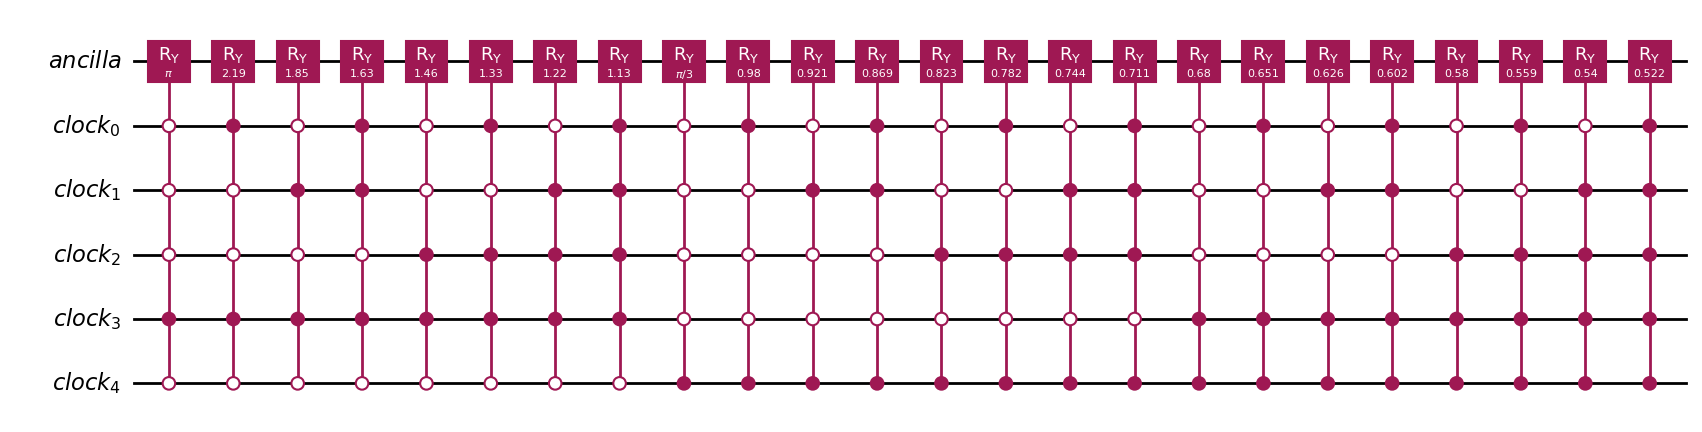

In [49]:
# --- Controlled-rotation stage ---

# The controlled rotation acts on:
# - the ancilla target qubit
# - all clock qubits as controls
circuit_cry = QuantumCircuit(ancilla, clock, name='CRy-for-inversion')

controlled_rotation = [i + 1 for i in range(n_clock)] + [0]

# Smallest relevant clock index used to define the rescaling constant
MIN_eigen = nearest_idx[0] - 2

for i in range(1, len(values_clock)):
    # Apply a multi-controlled RY only to the clock states used in the inversion step
    if i >= MIN_eigen:
        angle = 2 * np.arcsin(MIN_eigen / values_clock[i])
        multicry = RYGate(angle).control(n_clock, ctrl_state=values_clock_bin[i])
        circuit_cry.append(multicry, controlled_rotation)

gate_cry = circuit_cry.to_gate()
circuit_cry.draw(output='mpl')

In [50]:
print("Reference clock index used in the controlled rotation:")
print(MIN_eigen)

Reference clock index used in the controlled rotation:
8


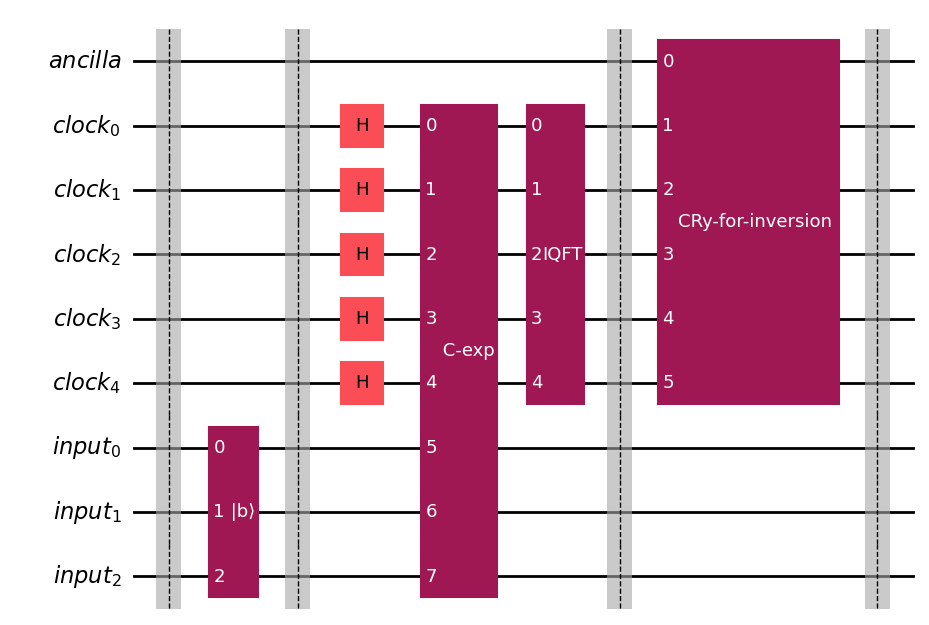

In [51]:
# Append the controlled-rotation gate to the full HHL circuit
append_rotation = [0] + [i + 1 for i in range(n_clock)]
circuit_shot.append(gate_cry, append_rotation)

circuit_shot.barrier()
circuit_shot.draw(output='mpl')

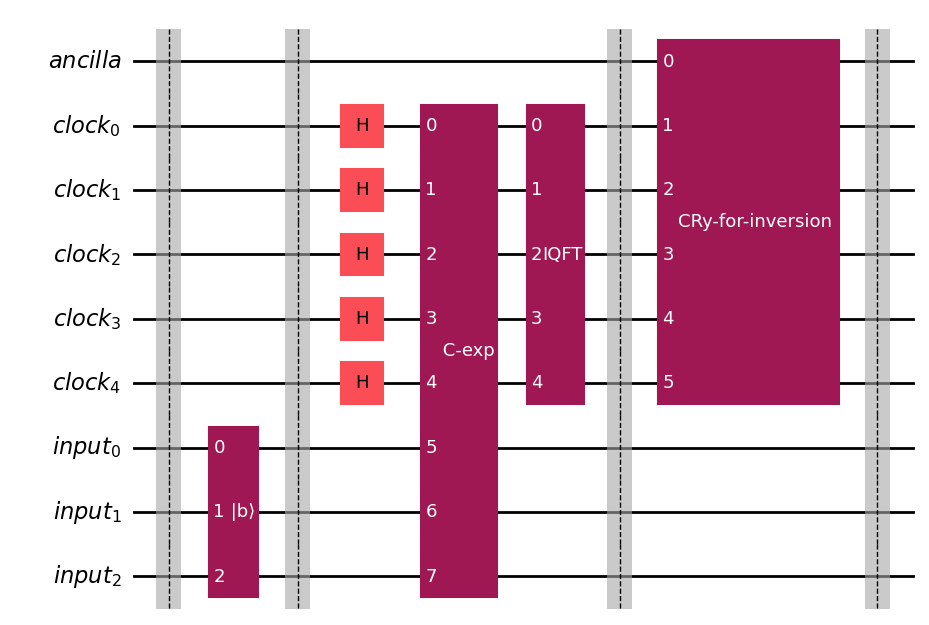

In [52]:
# At this stage we do not measure yet.
# The circuit remains fully coherent because we still have to uncompute the clock register.
circuit_shot.draw(output='mpl')

## 3.2 Uncompute the clock register

After the controlled rotation, the usual HHL workflow applies the inverse of the QPE block:

1. inverse QFT on the clock register,
2. inverse controlled time evolution,
3. final Hadamards on the clock qubits.

If everything is consistent, the clock register is approximately uncomputed and the useful information remains in the ancilla and input registers.

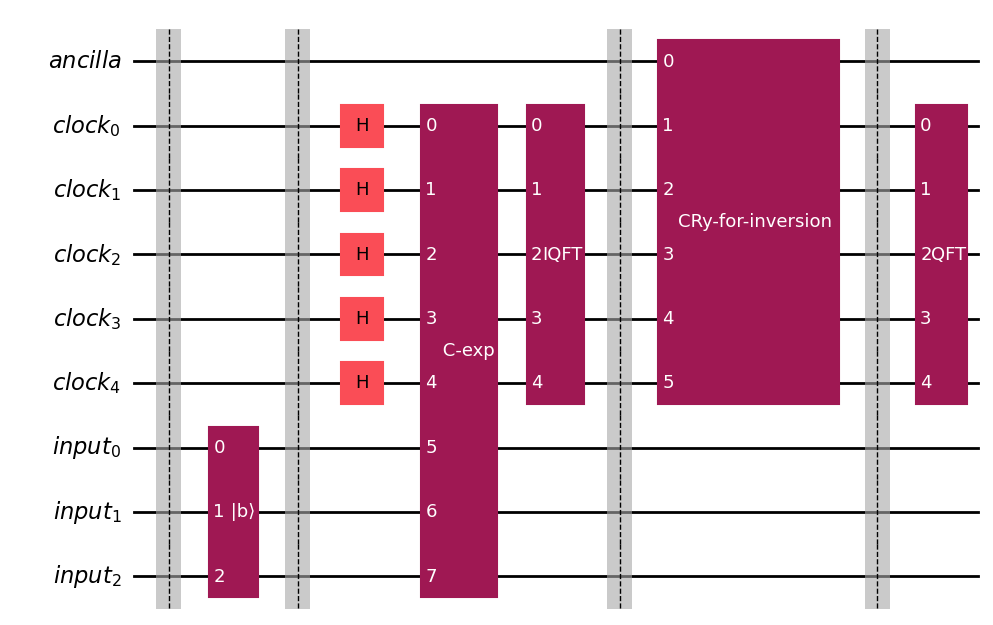

In [53]:
# --- Inverse QFT on the clock register ---
qft = QFT(n_clock)
circuit_shot.append(qft, clock)

circuit_shot.draw(output='mpl')

In [54]:
# --- Inverse controlled-U stage ---

# Rebuild the same evolution operator used in QPE, now to be applied in reverse
U = convert_A_to_gate(Gamma, time)

circuit_expmAt = QuantumCircuit(clock, input, name='iC-exp')

shifted_list_input = [x - 1 for x in list_input]

for i in range(n_clock - 1, -1, -1):
    # Reverse order and inverse power are both needed to undo the QPE evolution
    Upow = U.power(2**i).inverse()
    ctrl_Upow = Upow.control()
    circuit_expmAt.append(ctrl_Upow, [i, *shifted_list_input])

gate_expmAt = circuit_expmAt.to_gate()

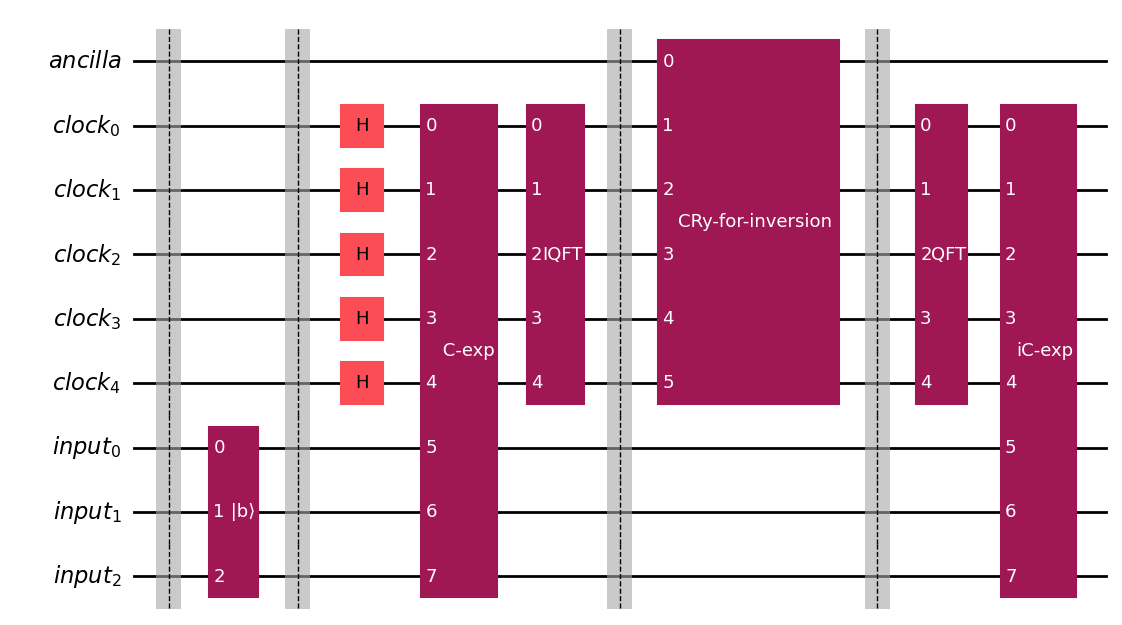

In [55]:
# Append the inverse controlled-U block to the full circuit
append_exponentiation = [i for i in range(1, n_clock + n_input + 1)]
circuit_shot.append(gate_expmAt, append_exponentiation)

circuit_shot.draw(output='mpl')

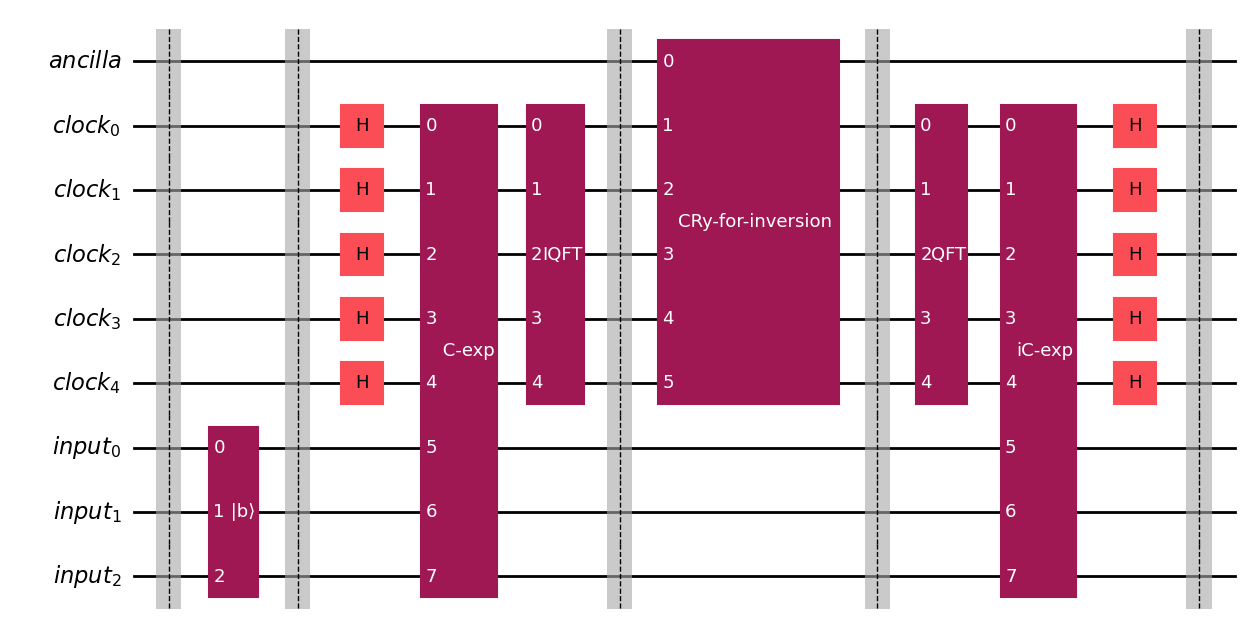

In [56]:
# Final Hadamard gates on the clock register complete the inverse-QPE uncomputation
circuit_shot.h(clock)

circuit_shot.barrier()
circuit_shot.draw(output='mpl')

## 3.3 Inspect the final HHL statevector and isolate the solution branch

We now simulate the full circuit and inspect the output state.  
The key idea is that the desired HHL solution is obtained from the branch where:

- the **ancilla qubit indicates success**,
- and, depending on the post-processing choice, the clock register is treated either explicitly or marginalized out.

The next cells therefore move from the full statevector to progressively simpler probability dictionaries.

In [57]:
statevector = Statevector.from_instruction(circuit_shot)
ideal_distribution = statevector.probabilities_dict()

# Extract amplitudes to inspect the full final statevector
amps = statevector.data
num_qubits = statevector.num_qubits

for i, amp in enumerate(amps):
    bitstring = format(i, f'0{num_qubits}b')
    print(f"|{bitstring}>: {amp:.3f}   prob: {np.abs(amp)**2:.3f}")

|000000000>: 0.301+0.000j   prob: 0.091
|000000001>: 0.324+0.000j   prob: 0.105
|000000010>: -0.000-0.003j   prob: 0.000
|000000011>: -0.000+0.001j   prob: 0.000
|000000100>: 0.000-0.007j   prob: 0.000
|000000101>: -0.000+0.006j   prob: 0.000
|000000110>: 0.003-0.000j   prob: 0.000
|000000111>: -0.006-0.000j   prob: 0.000
|000001000>: 0.000-0.013j   prob: 0.000
|000001001>: -0.000+0.013j   prob: 0.000
|000001010>: 0.004+0.000j   prob: 0.000
|000001011>: -0.006-0.000j   prob: 0.000
|000001100>: 0.006+0.000j   prob: 0.000
|000001101>: -0.013-0.000j   prob: 0.000
|000001110>: -0.000+0.000j   prob: 0.000
|000001111>: 0.000-0.003j   prob: 0.000
|000010000>: 0.000-0.004j   prob: 0.000
|000010001>: -0.000+0.011j   prob: 0.000
|000010010>: 0.001-0.000j   prob: 0.000
|000010011>: -0.005-0.000j   prob: 0.000
|000010100>: 0.002+0.000j   prob: 0.000
|000010101>: -0.011+0.000j   prob: 0.000
|000010110>: -0.000-0.000j   prob: 0.000
|000010111>: -0.000-0.003j   prob: 0.000
|000011000>: -0.009-0.000j 

In [58]:
print("Sanity check: total probability of the final statevector")
print(np.sum(np.abs(amps)**2))

Sanity check: total probability of the final statevector
0.9999999999997783


In [59]:
# Convert the probability dictionary to plain Python types for easier manipulation
clean_ideal_distribution = {str(k): float(v) for k, v in ideal_distribution.items()}

In [60]:
# Keep only the branch with:
# - ancilla = 1  (successful inversion)
# - clock register = 00...0 after uncomputation
filtered_trimmed_dict = {
    k[:-(n_clock + 1)]: v
    for k, v in clean_ideal_distribution.items()
    if k.endswith('0' * n_clock + '1')
}
probs = filtered_trimmed_dict

In [61]:
# Also compute the input-register marginal by summing over clock and ancilla states
input_probs = defaultdict(float)

for k, v in clean_ideal_distribution.items():
    # Extract only the input-register substring
    input_state = k[:n_input]
    
    # Sum over clock and ancilla states
    input_probs[input_state] += v

# Convert to a standard dictionary (optional)
input_probs = dict(input_probs)


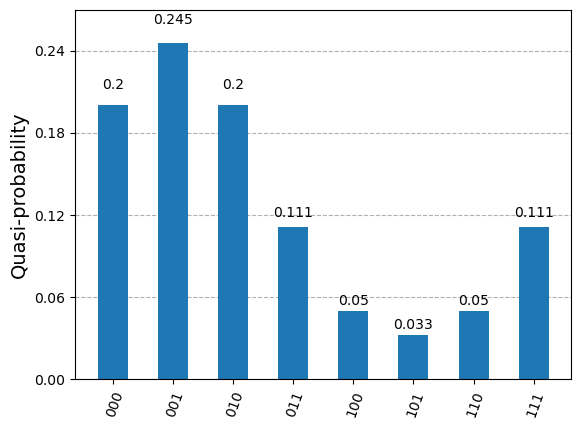

In [62]:
plot_histogram(input_probs)

In [63]:
# Normalize the input-register marginal so that it sums to 1
input_total = sum(input_probs.values())
normalized_input_probs = {k: v / input_total for k, v in input_probs.items()}
input_probs = normalized_input_probs

In [64]:
# Compare the probability of the selected success branch against the total probability
# Total probability (sum over all states)
total_prob = sum(clean_ideal_distribution.values())

# Filtered probability
filtered_prob = sum(filtered_trimmed_dict.values())

# Percentage
percentage = (filtered_prob / total_prob) * 100

print(f"Probabilità filtrata: {filtered_prob:.6f}")
print(f"Percentuale rispetto al totale: {percentage:.2f}%")

Probabilità filtrata: 0.555166
Percentuale rispetto al totale: 55.52%


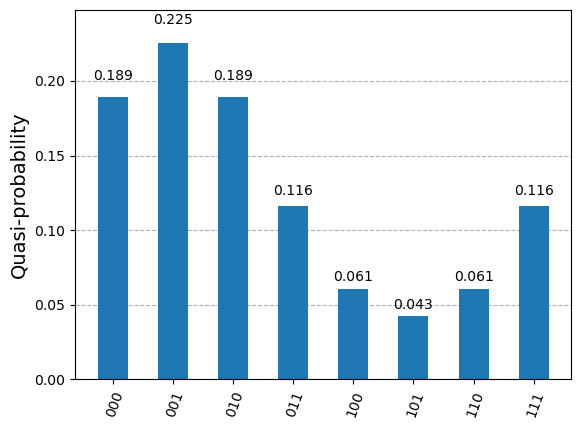

In [65]:
plot_histogram(probs)

In [66]:
# Normalize the post-selected solution branch
total = sum(probs.values())
normalized_probs = {k: v / total for k, v in probs.items()}
probs = normalized_probs

## 3.4 Reconstruct the quantum solution and compare it with the classical reference

The post-selected probabilities correspond to squared amplitudes.  
To recover the normalized solution vector, we therefore take the square root of the probabilities, and then rescale back to the physical temperature profile used in the heat-equation example.

Normalized HHL amplitudes:
[0.4352 0.4744 0.4352 0.3407 0.2461 0.207  0.2461 0.3407]


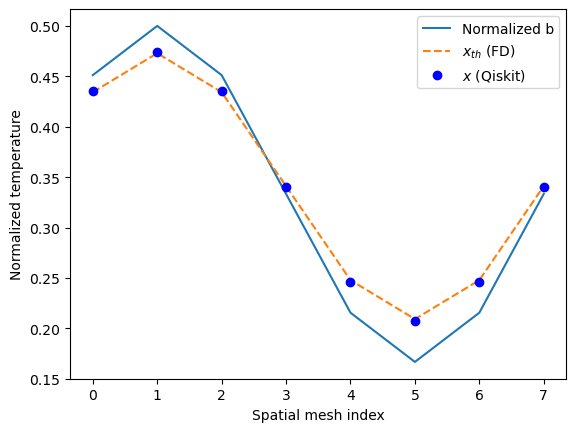

In [71]:
# Quantum solution obtained from the post-selected branch
y = np.real(list(probs.values()))   # probabilities
x = np.sqrt(y)                      # amplitudes

print("Normalized HHL amplitudes:")
print(x)

plt.plot(b, label='Normalized b')
plt.plot(x_th, label=r'$x_{th}$ (FD)', linestyle='dashed')
plt.plot(x, 'bo', label=r'$x$ (Qiskit)')
plt.legend()
plt.xlabel('Spatial mesh index')
plt.ylabel('Normalized temperature')
plt.show()

In [72]:
# Rescale the normalized HHL amplitudes back to the physical temperature scale
x_mean = statistics.mean(x)
T_mean = statistics.mean(T_old)
scale = T_mean / x_mean
print(f"scale = {scale}")

T_new_q = x * scale

scale = 2.9353379005951177


In [73]:
# Auxiliary quantities used in the analytical comparison
f = np.sqrt(TT_new / TT_old)
print(f)
g = f * (1 + 4 * r)
print(g)

0.9774251292133083
2.932275387639925


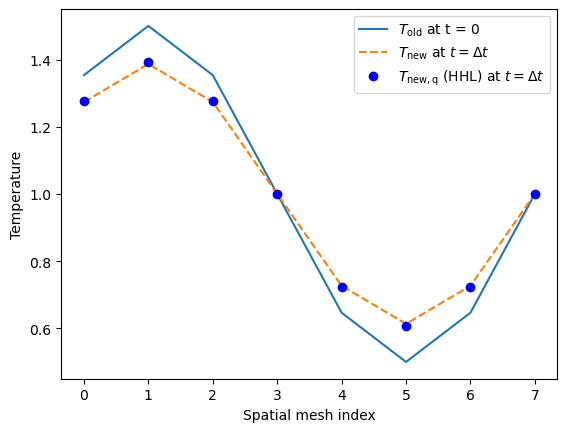

In [79]:
plt.plot(T_old, label=r'$T_\mathrm{old}$ at t = 0')
plt.plot(T_new, label=r'$T_\mathrm{new}$ at $t = \Delta t$', linestyle='dashed')
plt.plot(T_new_q, 'bo', label=r'$T_\mathrm{new,q}$ (HHL) at $t = \Delta t$')
plt.legend()
plt.xlabel('Spatial mesh index')
plt.ylabel('Temperature')
plt.show()

In [80]:
# Relative reconstruction error with respect to the classical reference
result = np.sum(np.abs(T_new_q - T_new) / (N * T_new))
print(result * 100)  # %

0.3897841947362917


In [81]:
print(f"{result:.2e}")

3.90e-03


## 3.5 Diagnostic check: effective eigenvalues recovered from the HHL output

The next cells compare the target eigenvalues with effective eigenvalues inferred from the reconstructed HHL solution.  
This is not a separate algorithmic step, but a useful diagnostic to understand how closely the finite-register implementation reproduces the intended inverse-eigenvalue action.

In [82]:
# Compare the target eigenvalues against the effective values inferred from the HHL output
b_Gamma = inv(eig_vec) @ b
x_Gamma = inv(eig_vec) @ x

eigenvalues_HHL = (b_Gamma / x_Gamma) / g

print("       eigenvalues =", " ".join(f"{x:.6f}" for x in eigenvalues))
print("   HHL eigenvalues =", " ".join(f"{x:.6f}" for x in eigenvalues_HHL))

       eigenvalues = 0.333333 0.430964 0.430964 0.666667 0.666667 0.902369 0.902369 1.000000
   HHL eigenvalues = 0.333681 0.425078 0.425078 0.000005 -0.000011 -0.000014 0.000098 0.000015


In [83]:
# Alternative post-processing estimate based on the finite-resolution clock weights
eigenvalues_HHL = np.zeros(N)
eigenvalues_IDX = np.zeros(N)

for j in range(N):
    mysum = 0
    for k in range(1, Nc):
        weight = (np.abs(alpha_Psi4[j][k]))**2
        mysum += weight / k

    eigenvalues_HHL[j] = 1 / ((Nc - 1) * mysum)
    eigenvalues_IDX[j] = 1 / ((Nc - 1) / nearest_idx[j])

print("       eigenvalues =", " ".join(f"{x:.6f}" for x in eigenvalues))
print("   IDX eigenvalues =", " ".join(f"{x:.6f}" for x in eigenvalues_IDX))
print("   HHL eigenvalues =", " ".join(f"{x:.6f}" for x in eigenvalues_HHL))

       eigenvalues = 0.333333 0.430964 0.430964 0.666667 0.666667 0.902369 0.902369 1.000000
   IDX eigenvalues = 0.322581 0.419355 0.419355 0.677419 0.677419 0.903226 0.903226 1.000000
   HHL eigenvalues = 0.321116 0.414894 0.414894 0.642841 0.642841 0.901836 0.901836 1.000000


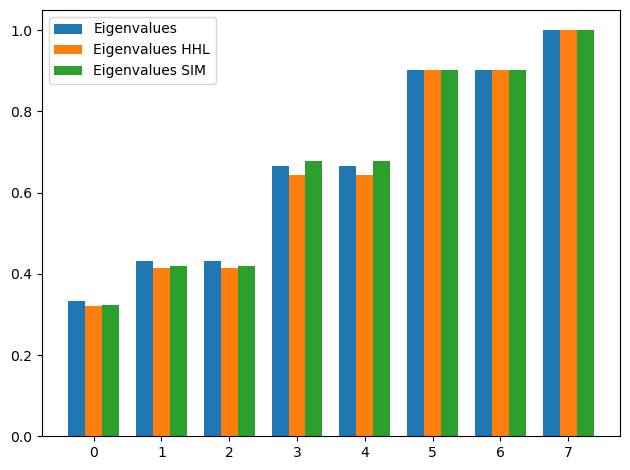

In [84]:
indices = np.arange(N)
width = 0.25

plt.bar(indices - width, eigenvalues, width=width, label="Eigenvalues")
plt.bar(indices, eigenvalues_HHL, width=width, label="Eigenvalues HHL")
plt.bar(indices + width, eigenvalues_IDX, width=width, label="Eigenvalues SIM")

plt.xticks(indices)
plt.legend()
plt.tight_layout()
plt.show()